In [1]:
!pip install fugashi ipadic

!wget https://www.rondhuit.com/download/ldcc-20140209.tar.gz
!tar -zxf ldcc-20140209.tar.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 35.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 4.3 MB/s eta 0:00:00
  Created wheel for ipadic: filename=ipadic-1.0.0-py3-none-any.whl size=13556704 sha256=4666b4be2c0440a0f215691a26953c542b1778da8b836c20bd92a6854d254ef2
  Stored in directory: /root/.cache/pip/wheels/93/8b/55/dd5978a069678c372520847cf84ba2ec539cb41917c00a2206
Successfully built ipadic
--2026-05-29 04:02:27--  https://www.rondhuit.com/download/ldcc-20140209.tar.gz
Resolving www.rondhuit.com (www.rondhuit.com)... 59.106.19.174
Connecting to www.rondhuit.com (www.rondhuit.com)|59.106.19.174|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8855190 (8.4M) [application/x-gzip]
Saving to: ‘ldcc-20140209.tar.gz’

ldcc-20140209.tar.g 100%[===================>]   8.44M   660KB/s    in 15s     

2026-05-29 04:02:43 (564 KB/s) - ‘ldcc-20140209.tar.gz’ saved [8855190/8855190]

In [2]:
import os
import glob
import fugashi
import ipadic

categories = [
    "dokujo-tsushin", "it-lifehack", "kaden-channel", "livedoor-homme",
    "movie-enter", "peachy", "smax", "sports-watch", "topic-news"
]

tagger = fugashi.GenericTagger(f"-d {ipadic.DICDIR} -r /dev/null")

def tokenize(text):
    return " ".join([word.surface for word in tagger(text)])

texts = []
labels = []

print("データの読み込みと分かち書きを開始します（数十秒かかります）...")

for label_id, category in enumerate(categories):
    file_paths = glob.glob(f"./text/{category}/{category}-*.txt")

    for path in file_paths:
        with open(path, "r", encoding="utf-8") as f:
            lines = f.read().splitlines()
            if len(lines) > 3:
                text = "".join(lines[2:])
                tokenized_text = tokenize(text)
                texts.append(tokenized_text)
                labels.append(label_id)

print(f"処理完了: 計 {len(texts)} 件のニュース記事を処理しました。")

print("\n--- データプレビュー（カテゴリ0） ---")
print(texts[0][:150] + "...")

データの読み込みと分かち書きを開始します（数十秒かかります）...
処理完了: 計 6497 件のニュース記事を処理しました。

--- データプレビュー（カテゴリ0） ---
ひとり 時間 が オンナ を 創る ！ 「 大好き な 彼 と は 一 秒 も 離れ たく ない 」 。 現在 、 彼 が い ない 人 や 交際 を はじめ た ばかり の 人 は 、 こんな ふう に 思っ て いる だろ う 。 しかし 、 時 が 過ぎれ ば どんなに 惹か れ 合う ふたり...


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import numpy as np

all_words = []
for text in texts:
    all_words.extend(text.split())

word_counts = Counter(all_words)
vocab = ["<PAD>", "<UNK>"] + [word for word, count in word_counts.most_common() if count >= 2]
word2idx = {word: idx for idx, word in enumerate(vocab)}

print(f"語彙数（総単語タイプ数）: {len(vocab)}")

MAX_LEN = 256
def text_to_indices(text, word2idx, max_len):
    tokens = text.split()
    indices = []
    for token in tokens:
        indices.append(word2idx.get(token, 1))

    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

encoded_texts = [text_to_indices(text, word2idx, MAX_LEN) for text in texts]

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset_size = len(encoded_texts)
train_size = int(dataset_size * 0.8)
test_size = dataset_size - train_size

full_dataset = TextDataset(encoded_texts, labels)
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

for X_batch, y_batch in train_loader:
    print(f"入力バッチの形状 [Batch Size, Sequence Length]: {X_batch.shape}")
    print(f"正解ラベルバッチの形状 [Batch Size]: {y_batch.shape}")
    break

語彙数（総単語タイプ数）: 45566
入力バッチの形状 [Batch Size, Sequence Length]: torch.Size([64, 256])
正解ラベルバッチの形状 [Batch Size]: torch.Size([64])


In [12]:
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, num_classes):
        super(TextCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=num_filters,
            kernel_size=3, #　単語の連結の長さ
            padding=1
        )

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(num_filters, num_classes)

    def forward(self, x):

        embedded = self.embedding(x)
        embedded = embedded.permute(0, 2, 1)

        conved = F.relu(self.conv(embedded))

        pooled = F.max_pool1d(conved, conved.shape[2]).squeeze(2)
        dropped = self.dropout(pooled)
        out = self.fc(dropped)

        return out


使用デバイス: cpu
学習を開始します...
Epoch 1/8 | Train Loss: 0.7345 | Test Accuracy: 89.38%
Epoch 2/8 | Train Loss: 0.1914 | Test Accuracy: 91.54%
Epoch 3/8 | Train Loss: 0.0699 | Test Accuracy: 93.54%
Epoch 4/8 | Train Loss: 0.0246 | Test Accuracy: 93.46%
Epoch 5/8 | Train Loss: 0.0124 | Test Accuracy: 94.23%
Epoch 6/8 | Train Loss: 0.0072 | Test Accuracy: 93.85%
Epoch 7/8 | Train Loss: 0.0060 | Test Accuracy: 93.38%
Epoch 8/8 | Train Loss: 0.0044 | Test Accuracy: 94.31%


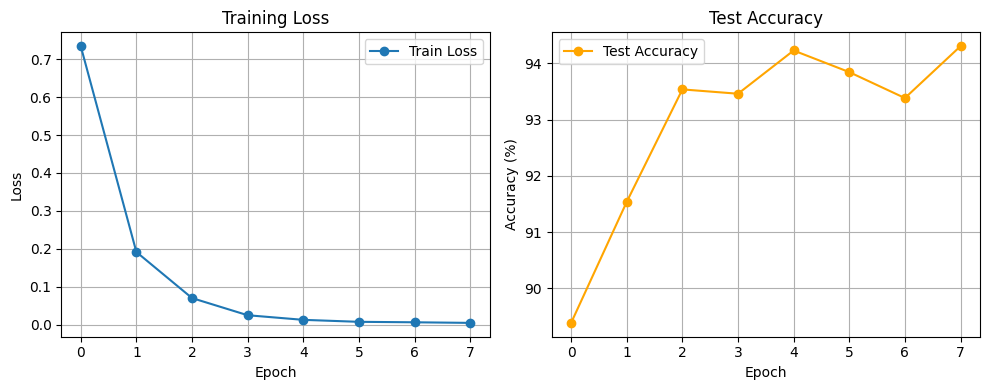

In [15]:
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用デバイス: {device}")

EMBED_DIM = 128   # 単語ベクトルの次元数
NUM_FILTERS = 256   # 畳み込み層のフィルタ数
NUM_CLASSES = 9     # Livedoorコーパスの9カテゴリ
EPOCHS = 8         # 学習を繰り返す回数

model = TextCNN(len(vocab), EMBED_DIM, NUM_FILTERS, NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_accuracies = []

print("学習を開始します...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0


    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy', color='orange', marker='o')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

使用デバイス: cpu

=== 実験開始: A (Baseline) ===
設定: {'embed': 128, 'filters': 256, 'kernel': 3, 'dropout': 0.5}
  Epoch 1/10 | Test Acc: 82.31%
  Epoch 2/10 | Test Acc: 87.31%
  Epoch 3/10 | Test Acc: 89.38%
  Epoch 4/10 | Test Acc: 90.38%
  Epoch 5/10 | Test Acc: 91.62%
  Epoch 6/10 | Test Acc: 91.15%
  Epoch 7/10 | Test Acc: 92.85%
  Epoch 8/10 | Test Acc: 93.31%
  Epoch 9/10 | Test Acc: 92.92%
  Epoch 10/10 | Test Acc: 94.08%
----------------------------------------
=== 実験開始: B (Overfitting) ===
設定: {'embed': 512, 'filters': 256, 'kernel': 3, 'dropout': 0.0}
  Epoch 1/10 | Test Acc: 89.54%
  Epoch 2/10 | Test Acc: 92.31%
  Epoch 3/10 | Test Acc: 94.46%
  Epoch 4/10 | Test Acc: 94.62%
  Epoch 5/10 | Test Acc: 94.62%
  Epoch 6/10 | Test Acc: 94.31%
  Epoch 7/10 | Test Acc: 94.69%
  Epoch 8/10 | Test Acc: 94.23%
  Epoch 9/10 | Test Acc: 94.77%
  Epoch 10/10 | Test Acc: 94.08%
----------------------------------------
=== 実験開始: C (Wide Context) ===
設定: {'embed': 128, 'filters': 256, 'kernel': 5,

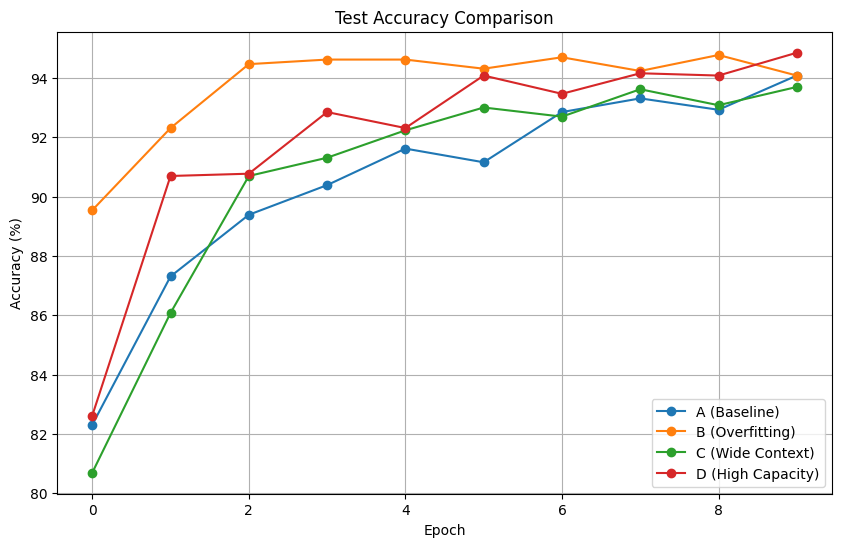

ベストモデル (D (High Capacity)) を使用して混同行列を生成します...


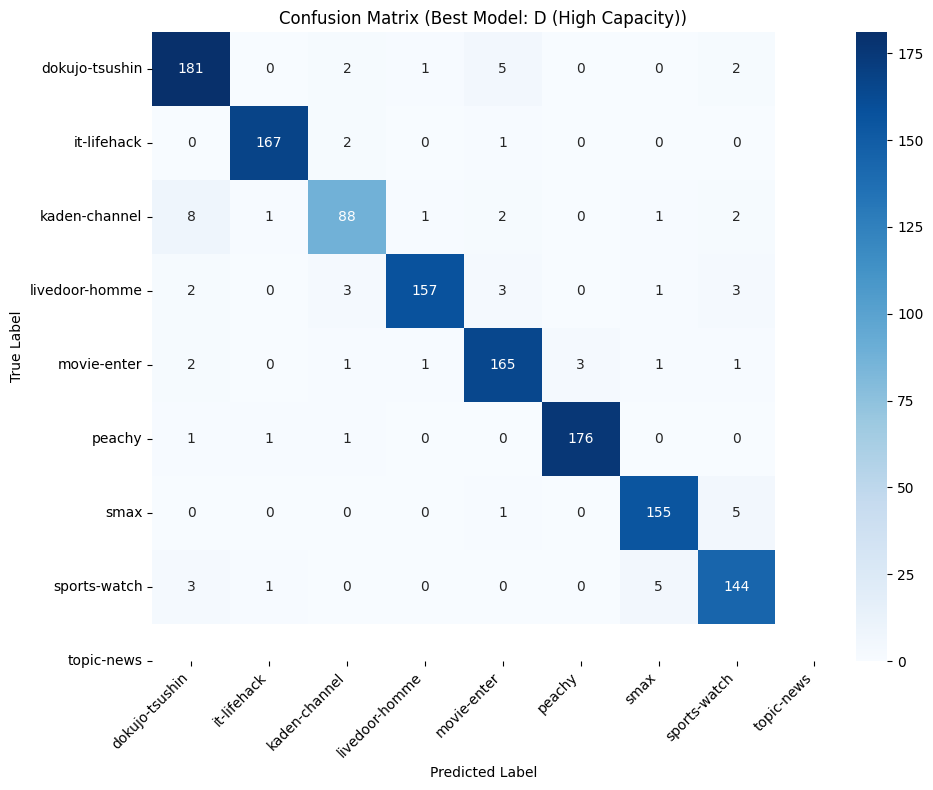

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import copy

class TunableTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, num_classes, kernel_size, dropout_rate):
        super(TunableTextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        padding_size = kernel_size // 2
        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=num_filters,
            kernel_size=kernel_size,
            padding=padding_size
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(num_filters, num_classes)

    def forward(self, x):
        embedded = self.embedding(x).permute(0, 2, 1)
        conved = F.relu(self.conv(embedded))
        pooled = F.max_pool1d(conved, conved.shape[2]).squeeze(2)
        dropped = self.dropout(pooled)
        out = self.fc(dropped)
        return out

configs = {
    "A (Baseline)":      {"embed": 128, "filters": 256, "kernel": 3, "dropout": 0.5},
    "B (Overfitting)":   {"embed": 512, "filters": 256, "kernel": 3, "dropout": 0.0},
    "C (Wide Context)":  {"embed": 128, "filters": 256, "kernel": 5, "dropout": 0.5},
    "D (High Capacity)": {"embed": 256, "filters": 512, "kernel": 3, "dropout": 0.6}
}

EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用デバイス: {device}\n")

best_accuracy = 0.0
best_model_name = ""
best_model_state = None
results = {}


for name, cfg in configs.items():
    print(f"=== 実験開始: {name} ===")
    print(f"設定: {cfg}")

    model = TunableTextCNN(
        vocab_size=len(vocab),
        embed_dim=cfg["embed"],
        num_filters=cfg["filters"],
        num_classes=9,
        kernel_size=cfg["kernel"],
        dropout_rate=cfg["dropout"]
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    test_acc_history = []

    for epoch in range(EPOCHS):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        accuracy = 100 * correct / total
        test_acc_history.append(accuracy)
        print(f"  Epoch {epoch+1}/{EPOCHS} | Test Acc: {accuracy:.2f}%")

    final_acc = test_acc_history[-1]
    results[name] = test_acc_history

    if final_acc > best_accuracy:
        best_accuracy = final_acc
        best_model_name = name
        best_model_state = copy.deepcopy(model.state_dict())

    print("-" * 40)

print(f"\n★ 最適パラメータ発見: {best_model_name} (精度: {best_accuracy:.2f}%) ★\n")

plt.figure(figsize=(10, 6))
for name, acc_history in results.items():
    plt.plot(acc_history, label=name, marker='o')
plt.title('Test Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

print(f"ベストモデル ({best_model_name}) を使用して混同行列を生成します...")

best_model = TunableTextCNN(
    vocab_size=len(vocab),
    embed_dim=configs[best_model_name]["embed"],
    num_filters=configs[best_model_name]["filters"],
    num_classes=9,
    kernel_size=configs[best_model_name]["kernel"],
    dropout_rate=configs[best_model_name]["dropout"]
).to(device)
best_model.load_state_dict(best_model_state)
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = best_model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title(f'Confusion Matrix (Best Model: {best_model_name})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()